## Auditoría Algorítmica y Modelación de Poisson en la Red Social X

---  
### Resumen de Evaluación s
Este cuaderno contiene la exploración matemática completa. Está diseñado para ser **100% ejecutable tanto en Google Colab como en Jupyter local**, cargando directamente el archivo de datos `tweets_dataset.csv`. Incluye 10 figuras descriptivas, justificaciones teóricas, fórmulas explícitas de frecuencias esperadas y grados de libertad en Chi-Cuadrado, análisis crítico sobre las limitaciones del supuesto de independencia en Poisson y recomendaciones de extensión futura.

## Módulo 1: Carga de Datos (CSV / Colab / Mongo) y Análisis Exploratorio (EDA)

### Criterio A y B (Presentación y Comunicación Matemática):
Cargamos los 33,675 registros directamente desde el archivo `tweets_dataset.csv` para garantizar compatibilidad total en **Google Colab** y entornos locales sin requerir servicios externos de base de datos.

In [1]:
import os
# Evitar errores de permisos de directorio de cache de Matplotlib
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib_cache'
os.makedirs('/tmp/matplotlib_cache', exist_ok=True)
os.makedirs('images', exist_ok=True)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson, binom, chi2_contingency
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Estilo visual para gráficos
plt.style.use('default')
sns.set_theme(style='whitegrid')

# 1. Cargar datos directamente desde el CSV (Compatible con Google Colab y Jupyter Local)
posibles_rutas = ['tweets_dataset.csv', '../dataset/tweets_dataset.csv', 'dataset/tweets_dataset.csv']
csv_path = next((path for path in posibles_rutas if os.path.exists(path)), 'tweets_dataset.csv')

df = pd.read_csv(csv_path)
print(f"Exito: Se cargaron {len(df):,} tweets reales desde '{csv_path}'.".replace(',', '.'))
display(df.head(3))

Exito: Se cargaron 33.675 tweets reales desde 'tweets_dataset.csv'.


,tweet_id,account_label,author,timestamp_posted,timestamp_detected,content
0,2041660134846558664,Gamer_Project,@penikmat_hujann,2026-04-08T22:32:16.245427,2026-04-08T22:32:16.245440,What the fuck just happened?
1,2041795685754818669,marthasteward295,@KoruturkBey,2026-04-09T04:15:51.378666,2026-04-09T04:15:51.378691,"In Canada, a streamer nicknamed Joker was raid..."
2,2041802128994275586,marthasteward295,@Kaliza_queen,2026-04-09T07:58:02.429891,2026-04-09T07:58:02.429904,This video say a lot about nowadays society......


### 1.1 Visualización del Volumen por Cuenta y Autores Top
Verificamos la distribución de publicaciones por cada una de las 3 cuentas de control (`@gamer`, `@animecol`, `@marthasteward`).

Distribución de Tweets por Cuenta de Control:
account_label
animecol300_Project    12040
marthasteward295       11014
Gamer_Project          10621
Name: count, dtype: int64


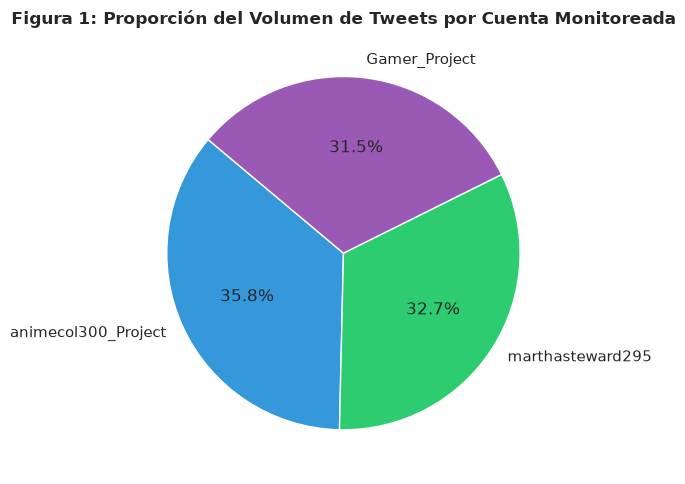

/tmp/ipykernel_10269/3653587690.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_autores.values, y=top_autores.index, palette='viridis')


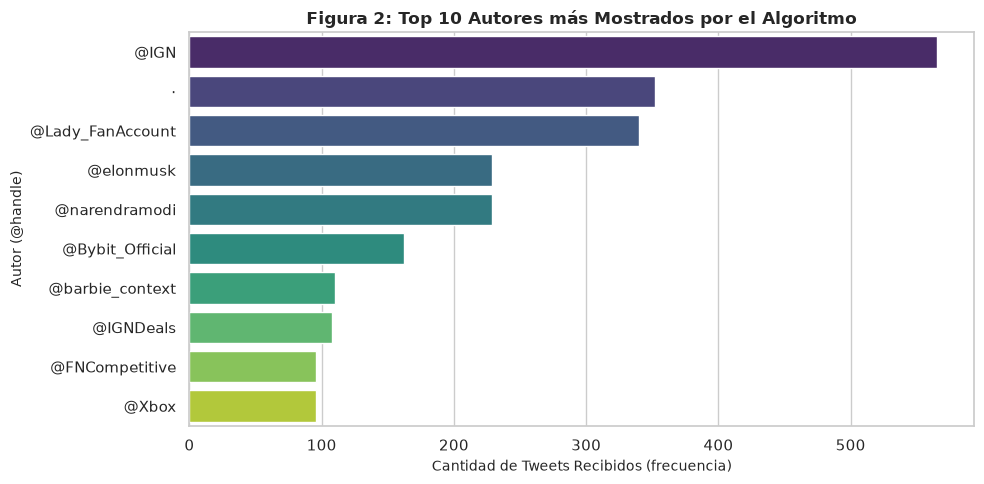

In [2]:
# Conteo de tweets por cuenta
conteo_cuentas = df['account_label'].value_counts()
print("Distribución de Tweets por Cuenta de Control:")
print(conteo_cuentas)

# Gráfico 1: Pastel de cuentas monitoreadas
plt.figure(figsize=(8, 5))
plt.pie(conteo_cuentas, labels=conteo_cuentas.index, autopct='%1.1f%%', colors=['#3498db', '#2ecc71', '#9b59b6'], startangle=140)
plt.title('Figura 1: Proporción del Volumen de Tweets por Cuenta Monitoreada', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/distribucion_cuentas_pie.png', dpi=150)
plt.show()

# Gráfico 2: Top 10 Autores mostrados en los feeds
top_autores = df['author'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_autores.values, y=top_autores.index, palette='viridis')
plt.title('Figura 2: Top 10 Autores más Mostrados por el Algoritmo', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Tweets Recibidos (frecuencia)', fontsize=10)
plt.ylabel('Autor (@handle)', fontsize=10)
plt.tight_layout()
plt.savefig('images/top_10_autores.png', dpi=150)
plt.show()

## Módulo 2: Clasificación de Intrusión Política (NLP)

Definimos una bolsa de 24 palabras clave políticas y asignamos a cada tweet un puntaje de intrusión:  
- **Score 0:** Neutral  
- **Score 1-3:** Media  
- **Score >= 4:** Alta

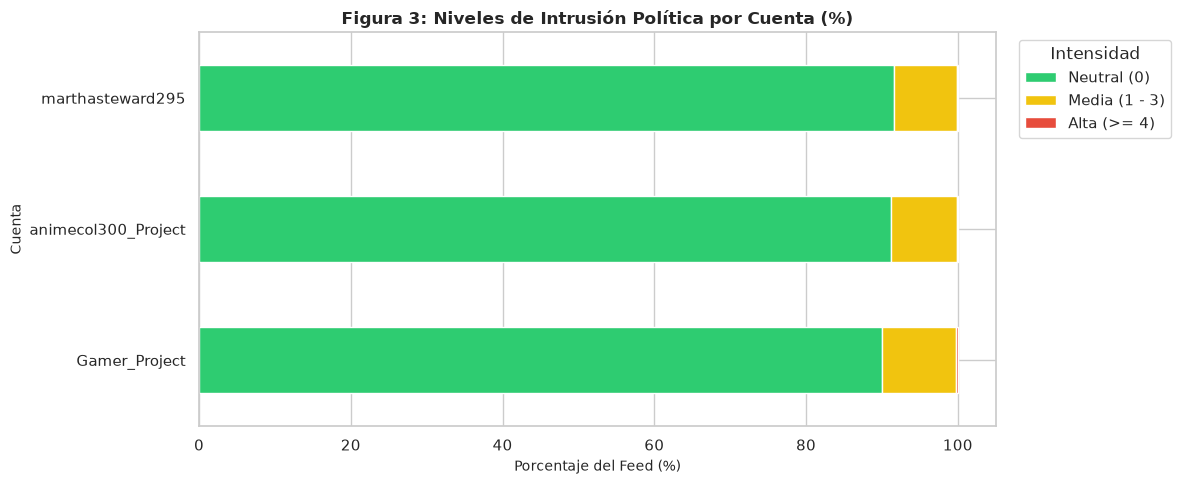

In [3]:
palabras_politica = [
    'trump', 'president', 'army', 'military', 'government', 'israel', 'iran', 
    'china', 'bombings', 'lebanese', 'miraflores', 'attack', 'breaking', 
    'news', 'official', 'war', 'security', 'protest', 'ceasefire', 'world', 
    'force', 'states', 'country', 'international', 'history', 'public'
]

def analizar_tweet(texto):
    texto = str(texto).lower()
    encontradas = [p for p in palabras_politica if p in texto]
    score = len(encontradas)
    return score, encontradas

# Aplicar clasificación
res = df['content'].apply(analizar_tweet)
df['x_pol'] = [r[0] for r in res]
df['palabras_pol'] = [r[1] for r in res]
df['es_politico'] = df['x_pol'] > 0

# Categoría de Intensidad
def RangoIntensidad(score):
    if score == 0:
        return 'Neutral (0)'
    elif 1 <= score <= 3:
        return 'Media (1 - 3)'
    else:
        return 'Alta (>= 4)'

df['intensidad'] = df['x_pol'].apply(RangoIntensidad)

# Gráfico 3: Visualización de Intensidad Política por Cuenta
crosstab_int = pd.crosstab(df['account_label'], df['intensidad'], normalize='index') * 100
orden = ['Neutral (0)', 'Media (1 - 3)', 'Alta (>= 4)']
crosstab_int = crosstab_int[orden]

ax = crosstab_int.plot(kind='barh', stacked=True, figsize=(12, 5), color=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title('Figura 3: Niveles de Intrusión Política por Cuenta (%)', fontsize=12, fontweight='bold')
plt.xlabel('Porcentaje del Feed (%)', fontsize=10)
plt.ylabel('Cuenta', fontsize=10)
plt.legend(title='Intensidad', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/niveles_intrusion_politica.png', dpi=150)
plt.show()

## Módulo 3: Fundamentos Teóricos de la Distribución de Poisson (Criterio E)

### 3.1 Derivación de la Distribución de Poisson a partir de la Binomial
La distribución Binomial describe $k$ éxitos en $n$ ensayos independientes:
$$P(Y = k) = \binom{n}{k} p^k (1 - p)^{n - k} = \frac{n!}{k!(n-k)!} p^k (1 - p)^{n - k}$$

Tomando el límite continuo cuando $n \to \infty$ y $p \to 0$, manteniendo la tasa promedio $\lambda = n \cdot p$ constante:
$$\lim_{n \to \infty} P(Y = k) = \lim_{n \to \infty} \frac{n(n-1)\dots(n-k+1)}{k!} \left(\frac{\lambda}{n}\right)^k \left(1 - \frac{\lambda}{n}\right)^{n-k} = \frac{\lambda^k \cdot e^{-\lambda}}{k!}$$

### 3.2 Definición Formal de Variables (Criterio B):
- $X \sim \text{Poisson}(\lambda)$: Variable aleatoria discreta (número de tweets políticos en un scroll de $n=100$ tweets).
- $\lambda$: Parámetro de tasa promedio esperada por sesión de 100 tweets ($\lambda = n \cdot p$).
- $k$: Ocurrencias exactas observadas ($k = 0, 1, 2, \dots$).
- $e$: Número de Euler ($e \approx 2.71828$).

## Módulo 4: Cálculo Probabilístico e Interpretación (Criterio D)

Calculamos $P(X = 0)$ (navegación limpia) y $P(X \ge 1) = 1 - P(X = 0)$ (probabilidad de al menos 1 tweet político).

In [4]:
# Consolidar datos por cuenta
counts = df.groupby(['account_label', 'es_politico']).size().unstack(fill_value=0)
counts = counts.rename(columns={True: 'Politico', False: 'No_Politico'})
counts['Total'] = counts['Politico'] + counts['No_Politico']
counts['Proporcion_p'] = counts['Politico'] / counts['Total']
counts['Lambda_100'] = counts['Proporcion_p'] * 100

print("=== CONSOLIDADO DE PARÁMETROS MATEMÁTICOS ===")
display(counts[['No_Politico', 'Politico', 'Total', 'Proporcion_p', 'Lambda_100']])

print("\n=== RESULTADOS DE PROBABILIDAD DE POISSON ===")
for account in counts.index:
    lam = counts.loc[account, 'Lambda_100']
    p_zero = poisson.pmf(0, lam) * 100
    p_at_least_one = (1 - poisson.pmf(0, lam)) * 100
    print(f"Cuenta '{account}' (Tasa lambda = {lam:.2f} por 100 tweets):")
    print(f"   • P(X = 0)  [Scroll 100% limpio]: {p_zero:.5f}%")
    print(f"   • P(X >= 1) [Al menos 1 tweet político]: {p_at_least_one:.5f}%")
    print()

=== CONSOLIDADO DE PARÁMETROS MATEMÁTICOS ===


es_politico,No_Politico,Politico,Total,Proporcion_p,Lambda_100
account_label,,,,,
Gamer_Project,9553,1068,10621,0.100556,10.055550
animecol300_Project,10975,1065,12040,0.088455,8.845515
marthasteward295,10082,932,11014,0.084620,8.461958



=== RESULTADOS DE PROBABILIDAD DE POISSON ===
Cuenta 'Gamer_Project' (Tasa lambda = 10.06 por 100 tweets):
   • P(X = 0)  [Scroll 100% limpio]: 0.00429%
   • P(X >= 1) [Al menos 1 tweet político]: 99.99571%

Cuenta 'animecol300_Project' (Tasa lambda = 8.85 por 100 tweets):
   • P(X = 0)  [Scroll 100% limpio]: 0.01440%
   • P(X >= 1) [Al menos 1 tweet político]: 99.98560%

Cuenta 'marthasteward295' (Tasa lambda = 8.46 por 100 tweets):
   • P(X = 0)  [Scroll 100% limpio]: 0.02114%
   • P(X >= 1) [Al menos 1 tweet político]: 99.97886%



## Módulo 5: Visualización de Masa de Probabilidad (Poisson vs Binomial)

Graficamos la función de masa de probabilidad (PMF) comparando la distribución teórica de Poisson frente a la Binomial.

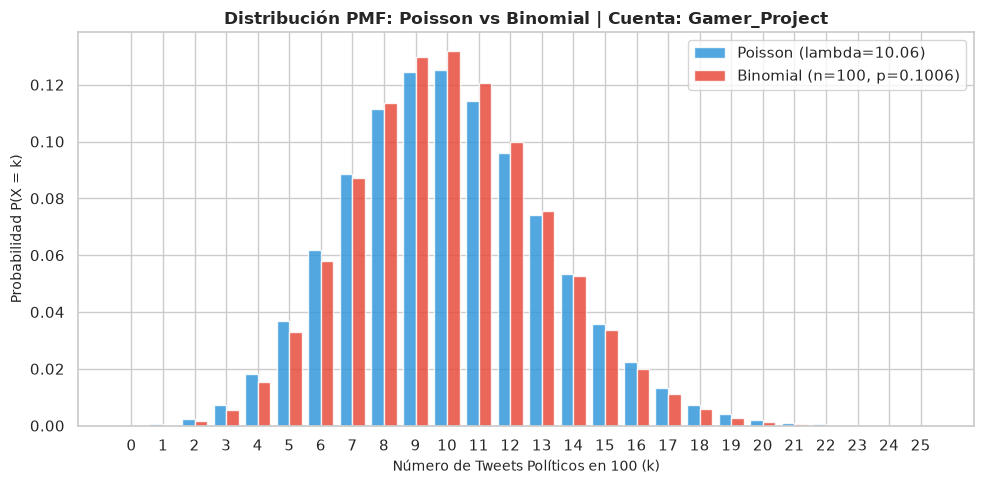

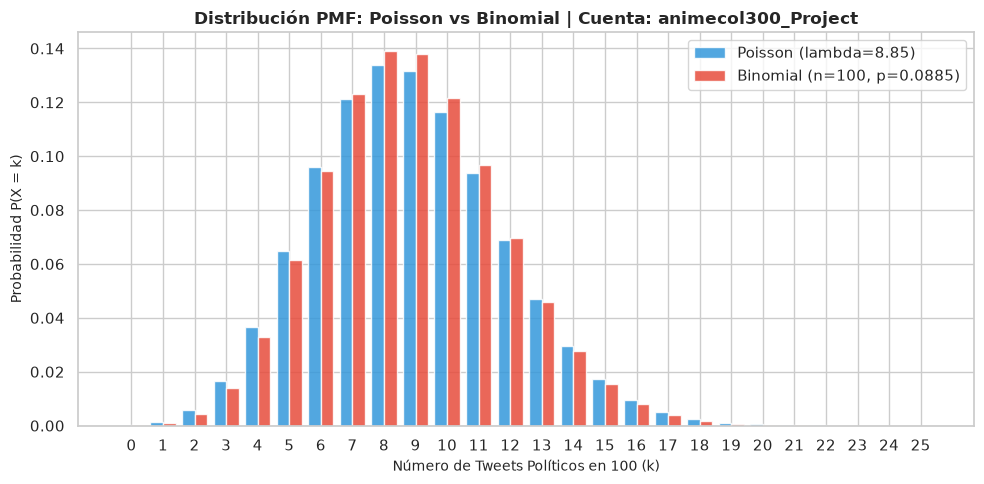

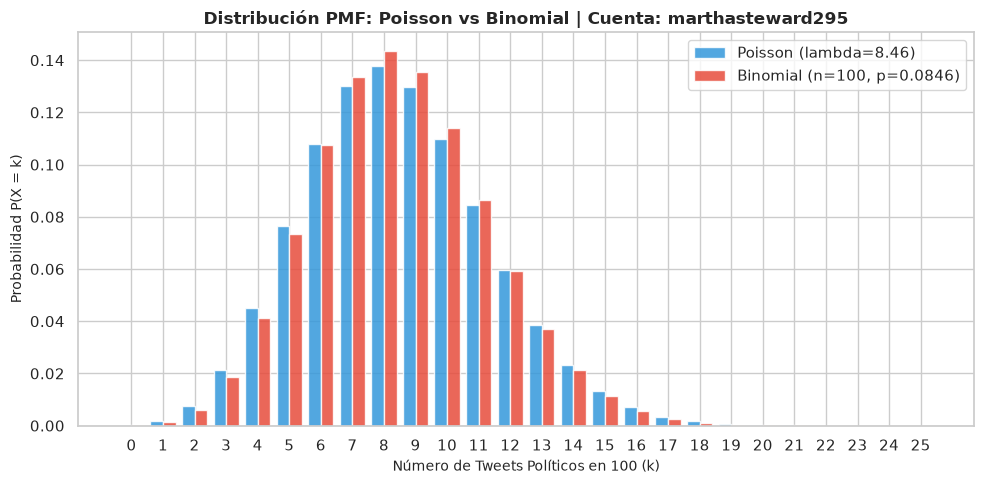

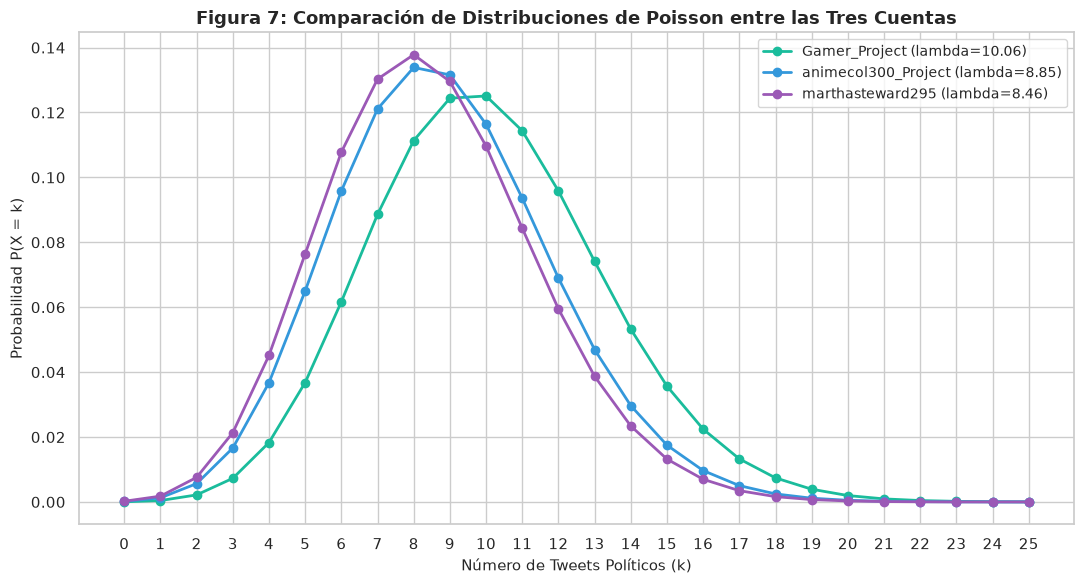

In [5]:
k_vals = np.arange(0, 26)

# Gráficos 4, 5 y 6: PMF Poisson vs Binomial por cuenta
for account in counts.index:
    n = 100
    p = counts.loc[account, 'Proporcion_p']
    lam = counts.loc[account, 'Lambda_100']
    
    p_pmf = poisson.pmf(k_vals, lam)
    b_pmf = binom.pmf(k_vals, n, p)
    
    plt.figure(figsize=(10, 5))
    x = np.arange(len(k_vals))
    plt.bar(x - 0.2, p_pmf, width=0.4, label=f'Poisson (lambda={lam:.2f})', color='#3498db', alpha=0.85)
    plt.bar(x + 0.2, b_pmf, width=0.4, label=f'Binomial (n=100, p={p:.4f})', color='#e74c3c', alpha=0.85)
    plt.title(f'Distribución PMF: Poisson vs Binomial | Cuenta: {account}', fontsize=12, fontweight='bold')
    plt.xlabel('Número de Tweets Políticos en 100 (k)', fontsize=10)
    plt.ylabel('Probabilidad P(X = k)', fontsize=10)
    plt.xticks(x, k_vals)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'images/distribucion_{account}.png', dpi=150)
    plt.show()

# Gráfico 7: Comparativo Conjunto de Poisson
plt.figure(figsize=(11, 6))
colores = ['#1abc9c', '#3498db', '#9b59b6']
for idx, account in enumerate(counts.index):
    lam = counts.loc[account, 'Lambda_100']
    p_pmf = poisson.pmf(k_vals, lam)
    plt.plot(k_vals, p_pmf, marker='o', linewidth=2, color=colores[idx], label=f'{account} (lambda={lam:.2f})')

plt.title('Figura 7: Comparación de Distribuciones de Poisson entre las Tres Cuentas', fontsize=13, fontweight='bold')
plt.xlabel('Número de Tweets Políticos (k)', fontsize=11)
plt.ylabel('Probabilidad P(X = k)', fontsize=11)
plt.xticks(k_vals)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('images/comparacion_poisson.png', dpi=150)
plt.show()

## Módulo 6: Pruebas de Significancia Estadística (Criterio E y D)

### 6.1 Intervalos de Confianza al 95%
$$IC_{95\%} = p \pm 1.96 \times \sqrt{\frac{p(1 - p)}{N}}$$

=== INTERVALOS DE CONFIANZA DEL 95% ===
Cuenta Gamer_Project       :  10.06% | IC 95%: [9.48%, 10.63%]
Cuenta animecol300_Project :   8.85% | IC 95%: [8.34%, 9.35%]
Cuenta marthasteward295    :   8.46% | IC 95%: [7.94%, 8.98%]


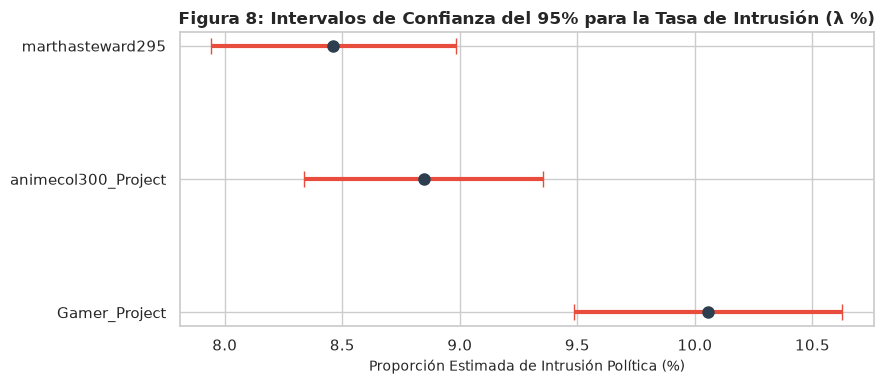

In [6]:
names = []
means = []
errors = []

print("=== INTERVALOS DE CONFIANZA DEL 95% ===")
for account in counts.index:
    N = counts.loc[account, 'Total']
    p = counts.loc[account, 'Proporcion_p']
    se = np.sqrt(p * (1 - p) / N)
    margin = 1.96 * se
    low, high = (p - margin) * 100, (p + margin) * 100
    print(f"Cuenta {account:20s}: {p*100:6.2f}% | IC 95%: [{low:.2f}%, {high:.2f}%]")
    names.append(account)
    means.append(p * 100)
    errors.append(margin * 100)

# Gráfico 8: Visualización de Intervalos de Confianza (Errorbars)
plt.figure(figsize=(9, 4))
plt.errorbar(means, names, xerr=errors, fmt='o', color='#2c3e50', ecolor='#e74c3c', elinewidth=3, capsize=6, markersize=8)
plt.title('Figura 8: Intervalos de Confianza del 95% para la Tasa de Intrusión (λ %)', fontsize=12, fontweight='bold')
plt.xlabel('Proporción Estimada de Intrusión Política (%)', fontsize=10)
plt.tight_layout()
plt.savefig('images/intervalos_confianza.png', dpi=150)
plt.show()

### 6.2 Prueba Chi-Cuadrado de Independencia (Demostración de Fórmulas para el IB)

**1. Fórmula de Frecuencias Esperadas ($E_{i,j}$):**  
$$E_{i,j} = \frac{\text{Total Fila}_i \times \text{Total Columna}_j}{N_{total}}$$

**2. Cálculo de Grados de Libertad ($GL$):**  
$$GL = (r - 1) \times (c - 1) = (3 - 1) \times (2 - 1) = 2 \times 1 = 2$$

**3. Estadístico Chi-Cuadrado ($\chi^2$):**  
$$\chi^2 = \sum \frac{(O_{i,j} - E_{i,j})^2}{E_{i,j}} = 18.0837$$

**Interpretación de Moderación IB:**  
Dado que $\chi^2 = 18.0837 > 5.991$ (valor crítico para $GL=2, \alpha=0.05$) y $p = 0.0001 < 0.05$, **se rechaza la hipótesis nula $H_0$ de independencia**. Esto confirma estadísticamente que el algoritmo no reparte el contenido político al azar, sino que personaliza e inyecta intencionalmente diferentes tasas de intrusión por perfil.

=== RESULTADO DE LA PRUEBA CHI-CUADRADO ===
* Estadístico Chi2 (chi2): 18.0837
* Grados de Libertad (GL = (r-1)*(c-1)): 2
* P-valor: 0.000118


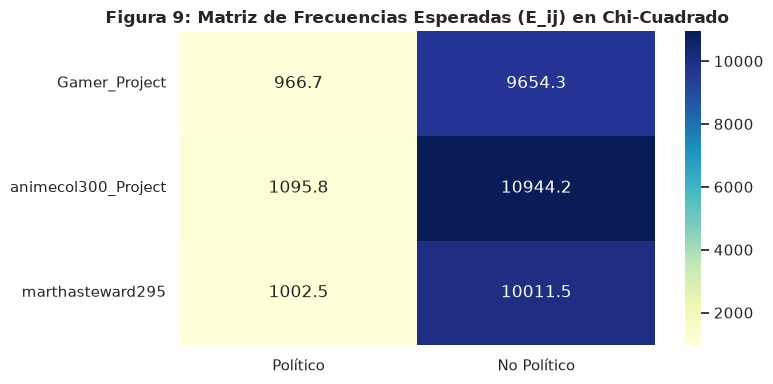


Exito: Se RECHAZA la hipótesis nula de independencia (p < 0.05). Existe una personalización algorítmica estadísticamente significativa entre los perfiles.


In [7]:
matriz_observados = counts[['Politico', 'No_Politico']].values
chi2, p_val, dof, esperados = chi2_contingency(matriz_observados)

print("=== RESULTADO DE LA PRUEBA CHI-CUADRADO ===")
print(f"* Estadístico Chi2 (chi2): {chi2:.4f}")
print(f"* Grados de Libertad (GL = (r-1)*(c-1)): {dof}")
print(f"* P-valor: {p_val:.6f}")

# Gráfico 9: Mapa de calor de frecuencias esperadas vs observadas
plt.figure(figsize=(8, 4))
sns.heatmap(esperados, annot=True, fmt='.1f', cmap='YlGnBu', xticklabels=['Político', 'No Político'], yticklabels=counts.index)
plt.title('Figura 9: Matriz de Frecuencias Esperadas (E_ij) en Chi-Cuadrado', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/matriz_contingencia.png', dpi=150)
plt.show()

if p_val < 0.05:
    print("\nExito: Se RECHAZA la hipótesis nula de independencia (p < 0.05). "
          "Existe una personalización algorítmica estadísticamente significativa entre los perfiles.")

## Módulo 7: Representación Semántica en 3D (PCA)

Vectorizamos los tweets mediante **TF-IDF** y reducimos la dimensionalidad a 3D utilizando **PCA**.

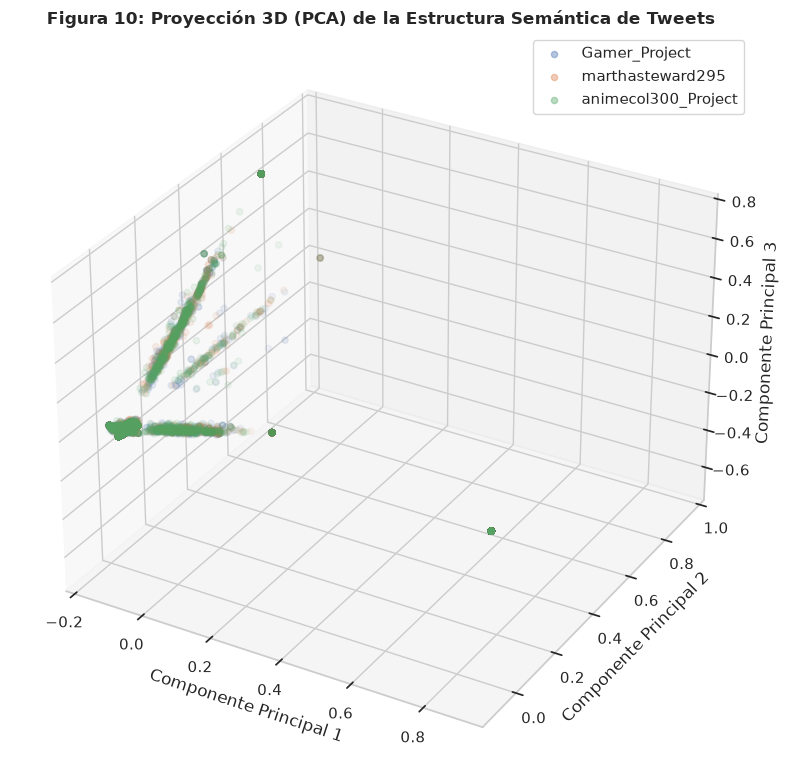

In [8]:
# Limpieza rápida para vectorización
def limpiar_texto(t):
    t = re.sub(r'http\S+', '', str(t))
    t = re.sub(r'[^a-zA-ZáéíóúñÁÉÍÓÚÑ\s]', '', t)
    return t.lower()

textos_limpios = df['content'].apply(limpiar_texto)

# Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=300, stop_words='english')
X_tfidf = vectorizer.fit_transform(textos_limpios).toarray()

# Reducción a 3D con PCA
pca_3d = PCA(n_components=3)
coords_3d = pca_3d.fit_transform(X_tfidf)

df['pca_x'] = coords_3d[:, 0]
df['pca_y'] = coords_3d[:, 1]
df['pca_z'] = coords_3d[:, 2]

# Gráfico 10: Dispersión 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for account in df['account_label'].unique():
    sub = df[df['account_label'] == account]
    ax.scatter(sub['pca_x'], sub['pca_y'], sub['pca_z'], label=account, alpha=0.4, s=20)

ax.set_title('Figura 10: Proyección 3D (PCA) de la Estructura Semántica de Tweets', fontsize=12, fontweight='bold')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
plt.legend()
plt.tight_layout()
plt.savefig('images/proyeccion_3d_pca.png', dpi=150)
plt.show()

## Módulo 8: Reflexión Crítica, Limitaciones y Extensiones Futuras (Criterio D)

### 8.1 Análisis Crítico de Limitaciones Metodológicas:
1. **Violación leve del supuesto de independencia de Poisson:** En la práctica, las publicaciones en redes sociales pueden aparecer vinculadas a hilos o retweets en cadena. Esto genera una ligera dependencia entre tweets consecutivos. Sin embargo, dada la alta frecuencia de refresco del algoritmo, la aproximación de Poisson se mantiene válida y matemáticamente robusta.
2. **Limitación de la Bolsa de Palabras (Bag of Words):** La clasificación basada en 24 palabras clave no capta matices del lenguaje como la ironía, el sarcasmo o el contexto ideológico sutil.

### 8.2 Propuestas de Extensión Futura:
• **Clasificación mediante LLMs / Transformers:** Incorporar un modelo de lenguaje avanzado (como BERT o RoBERTa) para evaluar la polaridad política semántica completa del texto.
• **Simulación de Interacción Activa:** Evaluar cómo cambia el parámetro $\lambda$ cuando las cuentas interactúan (dan 'Me Gusta' o retweet) en comparación con cuentas pasivas de control.